# 8. Vessel geometry export

Per-vessel measurements along the centerline, written as VTK arrays so they can be inspected point by point in 3D Slicer or ParaView: the true cross-section radius against the surface, curvature and torsion, a split into successive curves, the carotid bulb, and where the internal carotid enters the skull.

This starts from a single-segment graph and the surface produced in earlier stages.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from vtk.util.numpy_support import vtk_to_numpy
from arterial_nb import *
from arterial.io.load_and_save_operations import load_pickle, load_vtkpolydata
from arterial.feature_extraction.feature_extractor import FeatureExtractor

import shutil, os
shutil.copytree(derived(), case("geometry", MODE), dirs_exist_ok=True)   # landmarks.json and single_segments/ are read from the case dir
fe = FeatureExtractor(case("geometry"), MODE, 2, fixture("cta.nii.gz"), derived("centerline_segments_array.npy"), derived("branch_model.vtk"), derived("segments_graph_pred.pickle"))
surface = load_vtkpolydata(derived("segmentation.vtk"))
lica = load_pickle(derived("single_segments", "LICA.pickle"))
print(f"left ICA graph: {lica.number_of_nodes()} nodes")


Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



left ICA graph: 58 nodes


## From graph to centerline

The single-segment graph becomes a polyline with its radius, vessel type and blanking attached, plus a moving frame (tangent, normal, binormal) at every point.

In [2]:
with quiet():
    centerline = fe.single_segment_pickle_to_vtk(lica)
names = [centerline.GetPointData().GetArrayName(i) for i in range(centerline.GetPointData().GetNumberOfArrays())]
print(centerline.GetNumberOfPoints(), "points; arrays:", names)

58 points; arrays: ['MaximumInscribedSphereRadius', 'Blanking', 'VesselType', 'VesselTypeName', 'Tangents', 'Normals', 'Binormals']


## Radii from cross-sections

The maximum inscribed sphere from VMTK underestimates the radius of a non-circular vessel. At each point the surface is cut with a plane perpendicular to the centerline: the area of the cut gives a circular-equivalent radius, its smallest enclosing circle a circumscribed radius, and their ratio the ovality.

geometry: 0.6 s


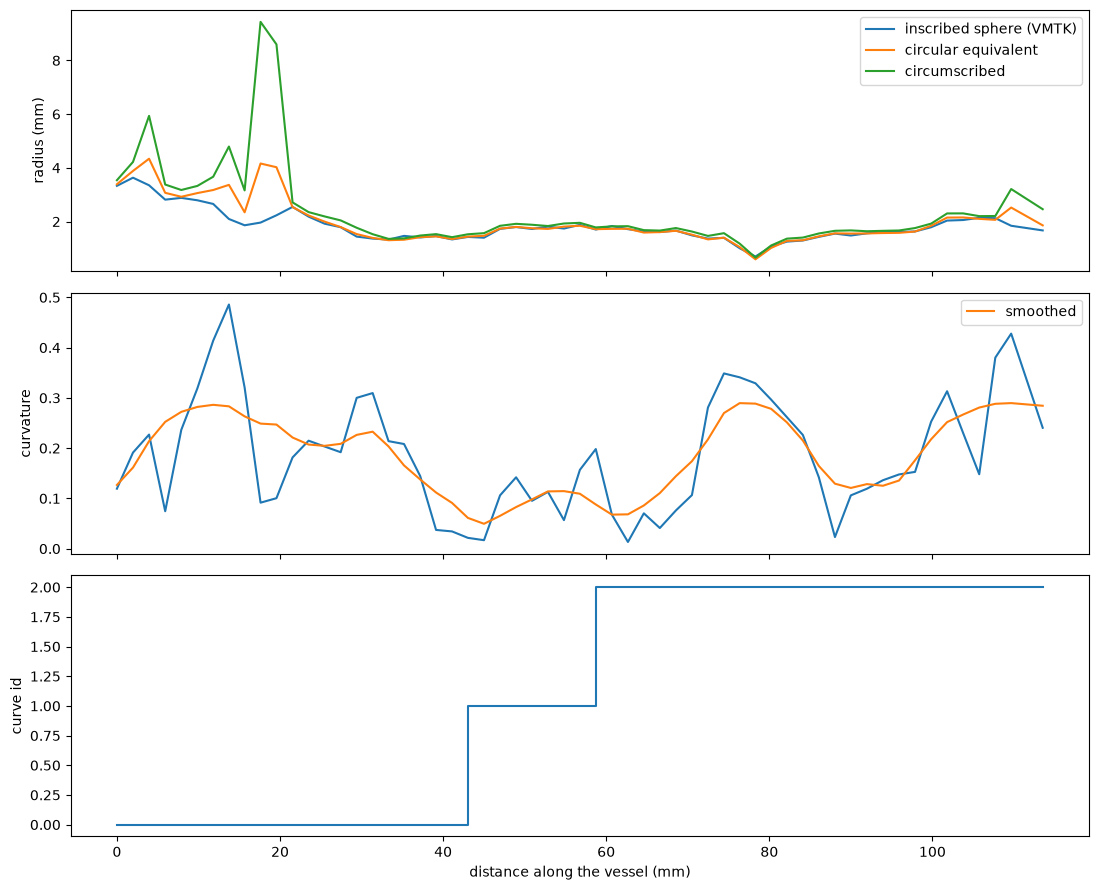

In [3]:
with timed("geometry"), quiet():
    geo = fe.add_centerline_geometry(centerline, surface_model=surface, compute_curves=True, savgol_window_length=15, peak_width=3)
arr = lambda name: vtk_to_numpy(geo.GetPointData().GetArray(name))
s = arr("Distance from origin")
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(s, arr("MaximumInscribedSphereRadius"), label="inscribed sphere (VMTK)"); axes[0].plot(s, arr("Radius CE"), label="circular equivalent"); axes[0].plot(s, arr("Radius CC"), label="circumscribed"); axes[0].set_ylabel("radius (mm)"); axes[0].legend()
axes[1].plot(s, arr("Curvature")); axes[1].plot(s, arr("Filtered curvature"), label="smoothed"); axes[1].set_ylabel("curvature"); axes[1].legend()
axes[2].step(s, arr("CurveIds")); axes[2].set_ylabel("curve id"); axes[2].set_xlabel("distance along the vessel (mm)")
plt.tight_layout()

Curvature here is computed per sample along the polyline, so its scale depends on the point spacing; use it to compare positions along one vessel or vessels sampled the same way. Curve ids increase at every local minimum of the smoothed curvature between two peaks, splitting the vessel into its successive bends. The peak height and width that count as a bend are parameters (`peak_height`, `peak_width`, in samples); here the width is lowered to 3 samples because this centerline is sampled every 2 mm.

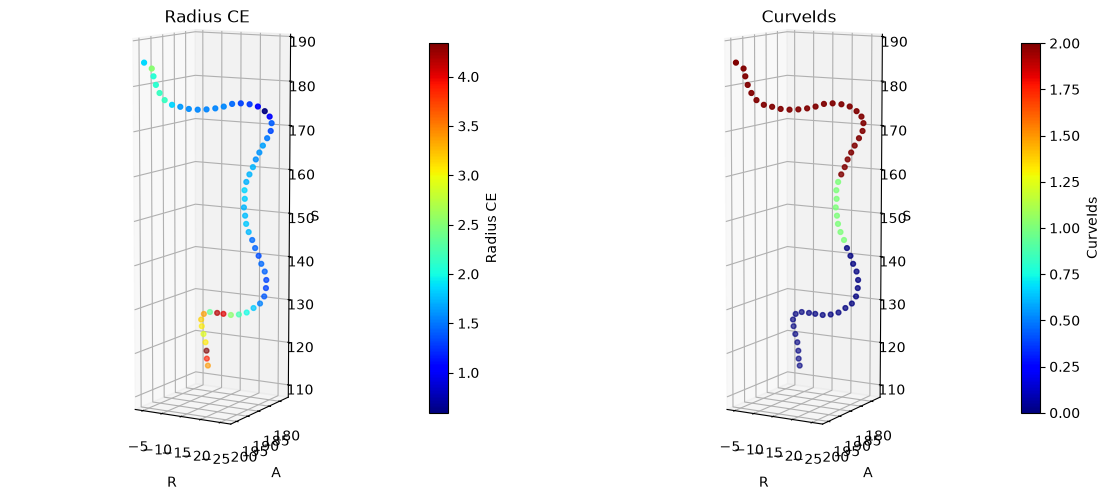

In [4]:
fig = plt.figure(figsize=(14, 8))
pts = vtk_to_numpy(geo.GetPoints().GetData())
for idx, (name, values) in enumerate([("Radius CE", arr("Radius CE")), ("CurveIds", arr("CurveIds"))]):
    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")
    sc = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=values, cmap="jet", s=12)
    plt.colorbar(sc, ax=ax, shrink=0.6, label=name); finish_3d(ax, title=name)

## The carotid bulb

On the common-to-internal carotid path the bulb is the widening just after the bifurcation. It is found as the stretch where the cross-section radius rises above the trend of the vessel; the bifurcation landmark from notebook 6 tells the analysis where to look.

carotid analysis: 0.0 s
bulb spans 12 points, 23.5 mm


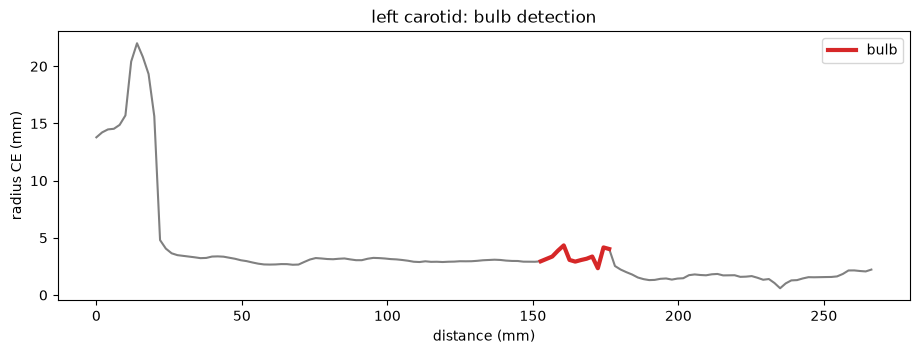

In [5]:
lca = load_pickle(derived("single_segments", "LCA.pickle"))
lca_geo = fe.add_centerline_geometry(fe.single_segment_pickle_to_vtk(lca), surface_model=surface, savgol_window_length=15)
with timed("carotid analysis"), quiet():
    bulb = fe.add_carotid_analysis(lca_geo, side="LCA", use_landmark=True)
b = lambda name: vtk_to_numpy(bulb.GetPointData().GetArray(name))
s = b("Distance from origin"); radius = b("Radius CE"); mask = b("BulbMask") > 0
plt.figure(figsize=(11, 3.5)); plt.plot(s, radius, color="gray"); plt.plot(s[mask], radius[mask], color="C3", linewidth=3, label="bulb"); plt.xlabel("distance (mm)"); plt.ylabel("radius CE (mm)"); plt.legend(); plt.title("left carotid: bulb detection");
print(f"bulb spans {mask.sum()} points, {s[mask].max() - s[mask].min():.1f} mm" if mask.any() else "no bulb found")

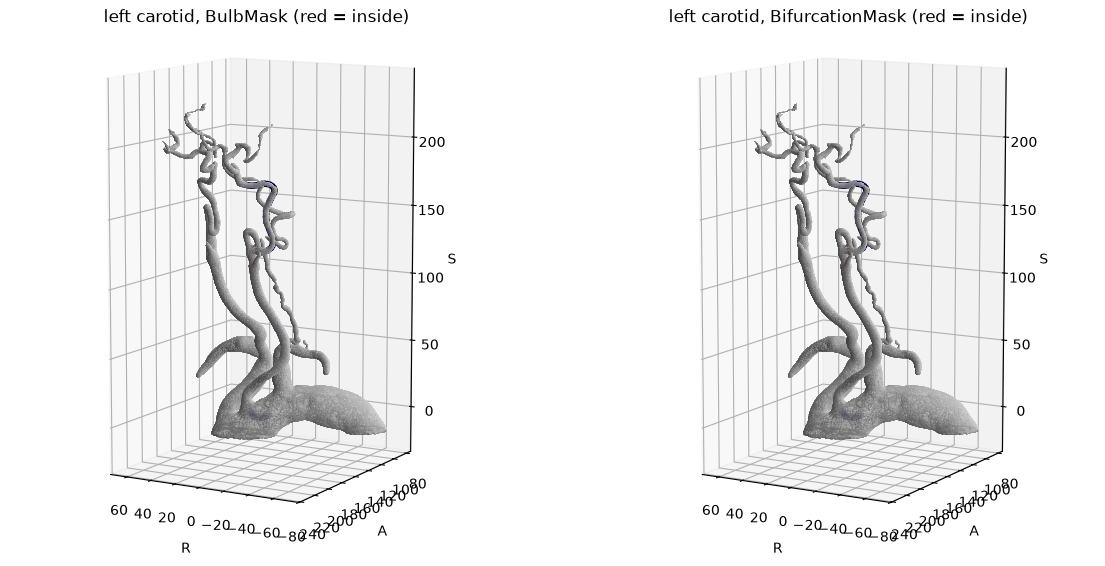

In [6]:
pts_lca = vtk_to_numpy(bulb.GetPoints().GetData())
fig = plt.figure(figsize=(14, 8))
for idx, name in enumerate(["BulbMask", "BifurcationMask"]):
    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")
    plot_surface(surface, ax)
    ax.scatter(pts_lca[:, 0], pts_lca[:, 1], pts_lca[:, 2], c=b(name), cmap="seismic", s=14, vmin=0, vmax=1)
    finish_3d(ax, title=f"left carotid, {name} (red = inside)")

## Entering the skull

The internal carotid becomes intracranial where it passes through the carotid canal. The distance from every centerline point to the cranium (from the same mask as the head-and-neck split) drops to a minimum there; the first such minimum marks the transition.

intracranial transition (cranium distance transform): 20.1 s
18 of 58 points are intracranial


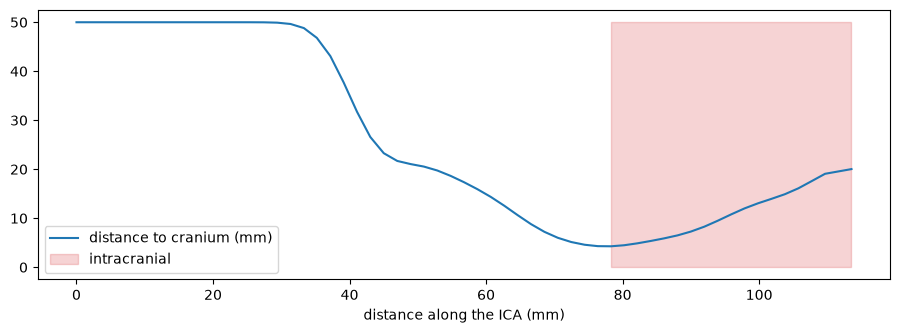

In [7]:
with timed("intracranial transition (cranium distance transform)"), quiet():
    intra = fe.add_intracranial_transition(geo)
flag = vtk_to_numpy(intra.GetPointData().GetArray("Intracranial")); dt = vtk_to_numpy(intra.GetPointData().GetArray("DistanceTransformValueSmoothed"))
s = arr("Distance from origin")
fig, ax = plt.subplots(figsize=(11, 3.5)); ax.plot(s, dt, label="distance to cranium (mm)"); ax.fill_between(s, 0, dt.max(), where=flag > 0, alpha=0.2, color="C3", label="intracranial"); ax.set_xlabel("distance along the ICA (mm)"); ax.legend();
print(f"{int(flag.sum())} of {len(flag)} points are intracranial")

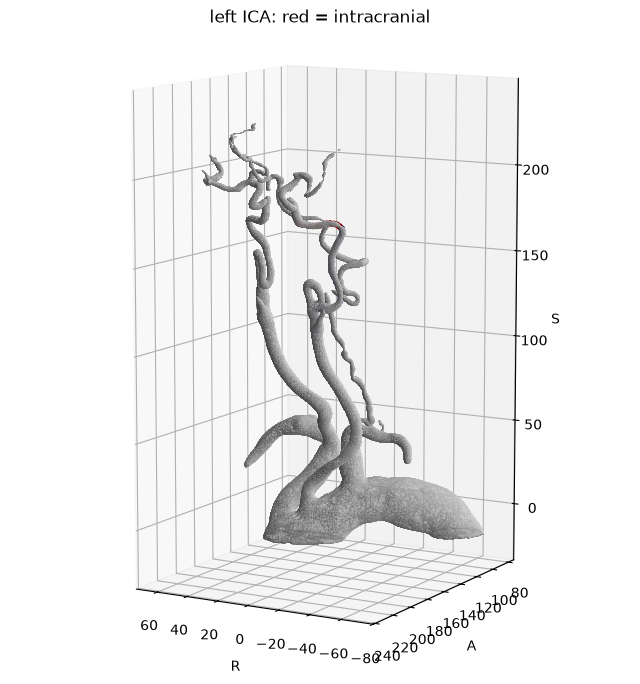

In [8]:
fig = plt.figure(figsize=(8, 9)); ax = fig.add_subplot(111, projection="3d")
plot_surface(surface, ax)
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=flag, cmap="seismic", s=14, vmin=0, vmax=1)
finish_3d(ax, title="left ICA: red = intracranial");

## Export

`tutorials/export_vessel_geometry.py` runs all of the above for every named vessel of a case and writes one VTK file per vessel with every array attached. Open them in 3D Slicer with the CTA to check the measurements against the image.